<a href="https://colab.research.google.com/github/MarcGaac/Linear-models/blob/main/Linear_models_FA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Initial Examination of the Data

c) Analysis of the distributions: Based on the histogram, it can be seen that the distribution of GDP per capita is extremely right-skewed. The fact is that most countries score low in this measure while there are only a few nations with incredibly high GDP per capita indicating that there are only a few very rich countries.

 d) Boxplot analysis: The boxplot confirms that the shape is almost entirely right-skewed. It also shows a number of outliers. These outliers are represented by points high above the highest point called the upper whisker.

Observations: 142, Variables: 6
          lifeExp     gdpPercap
count  142.000000    142.000000
mean    67.007423  11680.071820
std     12.073021  12859.937337
min     39.613000    277.551859
25%     57.160250   1624.842248
50%     71.935500   6124.371108
75%     76.413250  18008.835640
max     82.603000  49357.190170


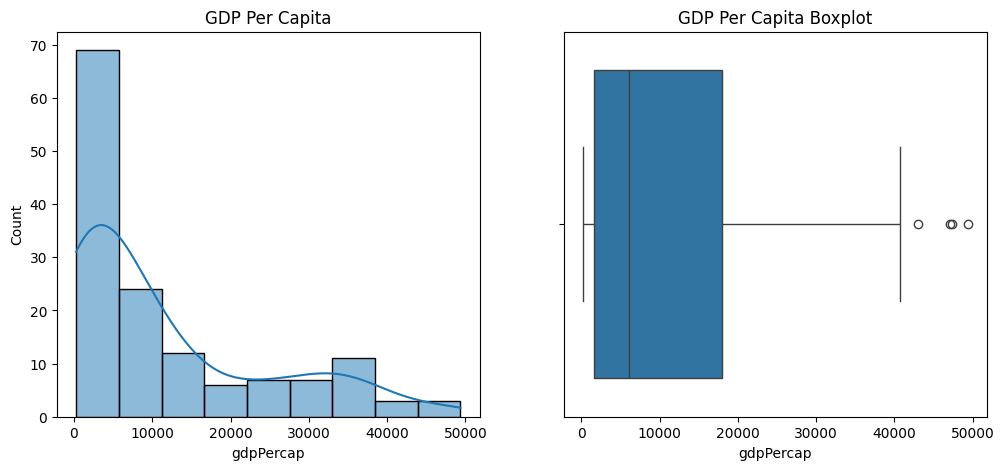

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load and filter data
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
df = pd.read_csv(url)
df_2007 = df[df['year'] == 2007].copy()

# A: Observations, Summaries, and Plots
print(f"Observations: {df_2007.shape[0]}, Variables: {df_2007.shape[1]}")
print(df_2007[['lifeExp', 'gdpPercap']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_2007['gdpPercap'], kde=True, ax=axes[0]).set_title('GDP Per Capita')
sns.boxplot(x=df_2007['gdpPercap'], ax=axes[1]).set_title('GDP Per Capita Boxplot')
plt.show()

**Part B: Examine the Bivariate Relationship**

a) Direction, shape, strength, dispersion: The dependence of the life expectancy on GDP is positive and somewhat strong but reveals a clear non-linear nature. The dispersion among poor countries is greater than that among rich ones.

b) LOWESS fitted conditional curve: The LOWESS line grows rapidly at low levels of GDP and then remains horizontal. This reflects the fact that small wealth additions bring much increased life expectancy for poorer countries, while wealthier countries show a diminishing return.

c) Straight-line sufficiency: Modeling the data using a straight line is completely unsuitable. Highly nonlinear relations, unequal spreads, and significant clustering of points on the low GDP axis make it impossible.

d) Role of scatterplots & Anscombe’s quartet: The scatterplot has to be analyzed as numerical measures (e.g., correlations) may be the same for datasets that are unrelated contrary to what can be seen in Anscombe's quartet showing that without visualization of the data one would not be able to avoid fitting a straight line to data showing significant curvilinear relation.

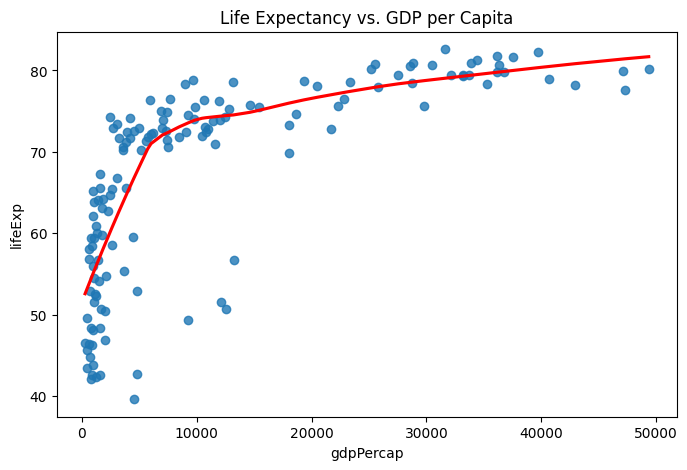

In [4]:
plt.figure(figsize=(8, 5))
sns.regplot(x='gdpPercap', y='lifeExp', data=df_2007, lowess=True, line_kws={'color': 'red'})
plt.title('Life Expectancy vs. GDP per Capita')
plt.show()

**Part C: Transformation of the Explanatory Variable**

  a) Reasons as to why the log transformation is a suitable method: Logarithmic transformation is a mathematically perfect choice for positive and strongly skewed variables in a right direction. It is capable of effectively compressing high values as compared to low ones which makes the spread more normalized and skewness decreases.

  b) Histogram comparison: While the original GDP per capita distribution is heavily right-skewed, the transformed $\log(\text{gdpPercap})$ distribution is much more symmetric and bell-shaped.
  
  c) Scatterplot comparison: Compared to the sharply curved original plot, the scatterplot of life expectancy against $\log(\text{gdpPercap})$ shows a relationship that is substantially closer to a straight line. The LOWESS smoother now follows a primarily linear, diagonal path.

  d) Assessment on symmetry: General statistics techniques for calculations, applying original data gives an extreme asymmetry ratio which is quite away from 1. Whereas the ratio after log transformation of data accurately moves to 1 thus confirming the fact that the distribution has become much better in terms of symmetry.

  e) Graphical evidence of progress: Log transformation evidently enhances data for the purpose of regression analysis since the method is capable of linearizing the bivariate relationship visualized in the plotted graph while it also might be noted that the histogram indicates symmetrical distribution of the independent variable.

In [5]:
df_2007['log_gdpPercap'] = np.log(df_2007['gdpPercap'])

def order_stat_ratio(series):
    q75, q50, q25 = series.quantile([0.75, 0.50, 0.25])
    return (q75 - q50) / (q50 - q25)

print(f"Original Symmetry Ratio: {order_stat_ratio(df_2007['gdpPercap']):.3f}")
print(f"Log Symmetry Ratio: {order_stat_ratio(df_2007['log_gdpPercap']):.3f}")

Original Symmetry Ratio: 2.641
Log Symmetry Ratio: 0.813


**Part D: Compare Regression Descriptions**

a) Model 1:$\text{lifeExp}=59.565650+0.000637 \cdot \text{gdpPercap}+\epsilon$

Model 2:$\text{lifeExp}=4.949612+7.202802 \cdot \log(\text{gdpPercap})+\epsilon$

b) In terms of number comparison, Model 2 demonstrates an obvious advantage over Model 1 in terms of $R^{2}$. This signifies that the log-transformed model can explain a larger percentage of the overall variance in life expectancy.

c) As for the residuals analysis, the residual plot for Model 1 indicates a clear U-shaped curve, which is regarded as a classic sign of the existence of some nonlinearity that wasn’t captured. On the contrary, Model 2 shows that the residual plot has more or less randomly spotted points around the zero line, meaning that the linearity assumption has been more fulfilled.

d) When it comes to the model choice, Model 2 is clearly the better option among the two. Numerically, it is better fitting, due to a larger $R^{2}$. From a graphical perspective, the residual plot provides evidence of the successful log transformation that has solved the problem of strongly pronounced nonlinearity that Model 1 suffered from.

e) One of the main limitations is that the study is of observational character and not experimental. The results cannot mean that the fact that a country increases its GDP will simply bring about a longer life expectancy as there exists plenty of confounding factors (healthcare, sanitation

Model 1 R-squared: 0.461
Model 2 R-squared: 0.654
--- Model 1 Coefficients ---
Intercept    59.565650
gdpPercap     0.000637
dtype: float64

--- Model 2 Coefficients ---
Intercept        4.949612
log_gdpPercap    7.202802
dtype: float64


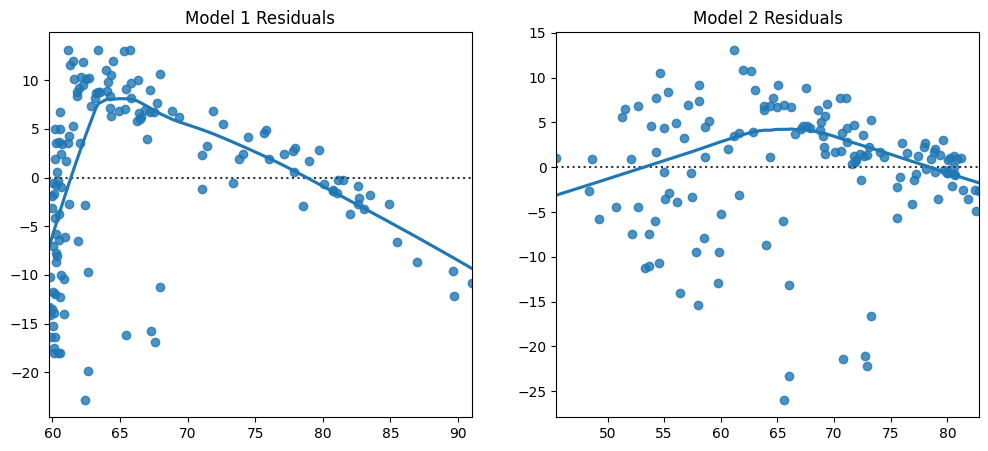

In [6]:
mod1 = smf.ols('lifeExp ~ gdpPercap', data=df_2007).fit()
mod2 = smf.ols('lifeExp ~ log_gdpPercap', data=df_2007).fit()

print(f"Model 1 R-squared: {mod1.rsquared:.3f}")
print(f"Model 2 R-squared: {mod2.rsquared:.3f}")
print("--- Model 1 Coefficients ---")
print(mod1.params)
print("\n--- Model 2 Coefficients ---")
print(mod2.params)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.residplot(x=mod1.fittedvalues, y=mod1.resid, lowess=True, ax=axes[0]).set_title('Model 1 Residuals')
sns.residplot(x=mod2.fittedvalues, y=mod2.resid, lowess=True, ax=axes[1]).set_title('Model 2 Residuals')
plt.show()